In [1]:
import torch
import torch.nn as nn
import torchsde
import matplotlib.pyplot as plt
import numpy as np
import os
from dotenv import load_dotenv; load_dotenv()
%cd {os.getenv('PROJECT_PATH')}

from control.model import LinearControlSDE
from control.contoller import OptimalRoute

/home/id94ebid/projects/neuroscience


In [2]:
dt = 1e-3
m, k, c = 1.0, 1.0, 0.5
A = torch.tensor([[0.0, 1.0],[-k/m, -c/m]])
B = torch.tensor([[0.0], [1.0/m]])

In [3]:
class ConstantControl(nn.Module):
    def __init__(self, B, cte: float):
        super().__init__()
        self.cte = float(cte)
        self.m = B.shape[1]

    def forward(self, t, y):
        bs = y.shape[0]
        return torch.full((bs, self.m), self.cte)
    
class SinusoidalControl(nn.Module):
    def __init__(self, B, bs: int):
        super().__init__()
        self.m = B.shape[1]
        self.bs = bs
        self.phase = 2*np.pi*torch.rand((self.bs, self.m))
        self.omega = 2 + 2*torch.rand((self.bs, self.m))

    def forward(self, t, y):
        return torch.sin(self.omega*t+self.phase)

# Train Set

In [ ]:
torch.manual_seed(1234)

# Initial condition: [position, velocity]
num_trajectories = 100

# Time span
t_span = [0.0, 5.0]
ts = torch.linspace(t_span[0], t_span[1], 100)
cte = [-1,0,1]

# Initialize spring-mass-damper system
y0 = [2*torch.randn((num_trajectories,2)) for i in range(len(cte))]
controls = [ConstantControl(B, i) for i in cte]
sdes = [LinearControlSDE(A, B, control_input=c_i, sigma=0.0) for c_i in controls]
ys = [torchsde.sdeint(sde_i, y0_i, ts, method="euler", dt=dt) for sde_i, y0_i in zip(sdes, y0)]

In [5]:
y_total = torch.concatenate(ys, dim=1)
u_total = torch.concatenate([c_i(ts, y_total).unsqueeze(-1).repeat(1,num_trajectories,1) for c_i in controls], dim=1)
print(y_total.shape)
print(u_total.shape)
print(ts.shape)
np.savez("data_processed/control/train.npz", y=y_total.numpy(), u=u_total.numpy(), t=ts.numpy())

torch.Size([100, 200, 2])
torch.Size([100, 200, 1])
torch.Size([100])


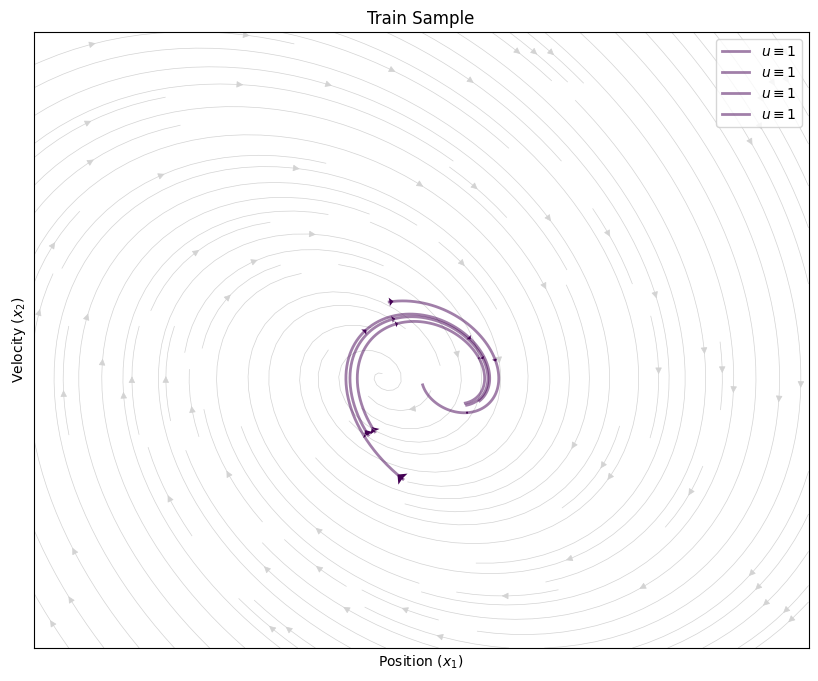

In [6]:
ts_np = ts.detach().numpy()
ys_np = ys[0].detach().numpy()

# Phase portrait
plt.figure(figsize=(10, 8))
num = 4
# Create a grid for the vector field
x1_range = np.linspace(ys_np[:, :, 0].min(), ys_np[:, :, 0].max()+0.01, 100)
x2_range = np.linspace(ys_np[:, :, 1].min(), ys_np[:, :, 1].max(), 100)
X1, X2 = np.meshgrid(x1_range, x2_range)

# Compute the vector field
Anp = A.detach().cpu().numpy()
U = Anp[0, 0] * X1 + Anp[0, 1] * X2
V = Anp[1, 0] * X1 + Anp[1, 1] * X2

# Plot streamlines
plt.streamplot(X1, X2, U, V, color='lightgray', density=1.5, linewidth=0.5, arrowsize=1)

# Plot trajectories
colors = plt.cm.viridis(np.linspace(0, 1, num))
for i,y in enumerate(ys):
    y_np = y.detach().numpy()
    plt.plot(y_np[:, :num, 0], y_np[:, :num, 1], alpha=0.5, linewidth=2, color=colors[i], label=f"$u\equiv {cte[i]}$")

    arrow_idx = np.arange(0, len(y_np)-1, len(y_np)//3)
    plt.quiver(y_np[arrow_idx, :num, 0], y_np[arrow_idx, :num, 1],
               y_np[arrow_idx+1, :num, 0] - y_np[arrow_idx, :num, 0],
               y_np[arrow_idx+1, :num, 1] - y_np[arrow_idx, :num, 1],
               color=colors[i], scale_units='xy', angles='xy', scale=1, width=0.003, headwidth=10)

plt.xlabel('Position ($x_1$)')
plt.ylabel('Velocity ($x_2$)')
plt.title('Train Sample')
#plt.grid(True, alpha=0.3)
plt.xticks([]); plt.yticks([])
plt.legend(loc='upper right')
plt.savefig('images/phase_portrait_train.png', dpi=300, bbox_inches='tight')
plt.show()

# Test set

In [7]:
torch.manual_seed(1234)

# Initial condition: [position, velocity]
num_trajectories = 256

# Time span
t_span = [0.0, 5.0]
ts = torch.linspace(t_span[0], t_span[1], 100)

# Initialize spring-mass-damper system
y0 = 2*torch.randn((num_trajectories,2))
control = SinusoidalControl(B, num_trajectories) 
sde = LinearControlSDE(A, B, control_input=control, sigma=0.0) 
ys = torchsde.sdeint(sde, y0, ts, method="euler", dt=dt)

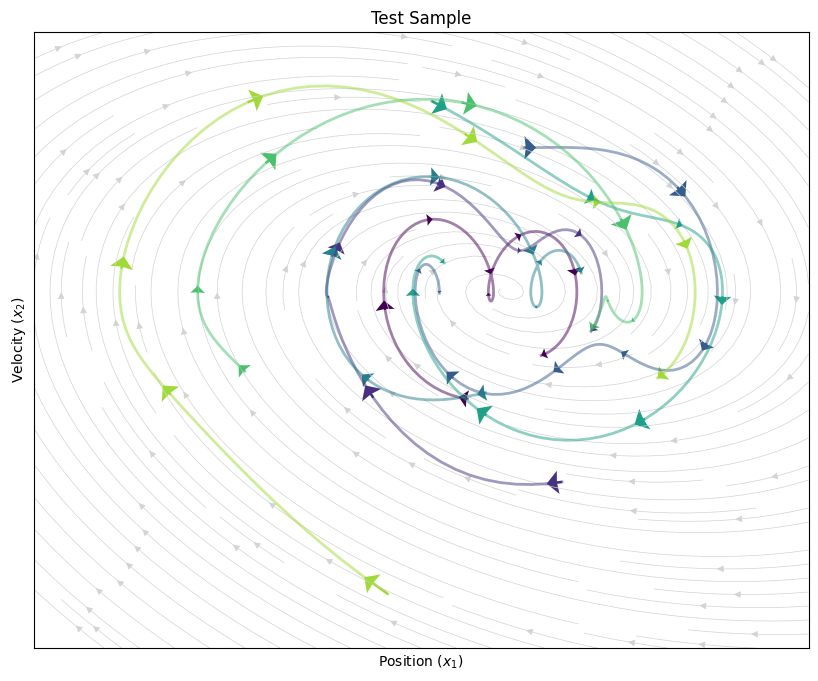

In [8]:
ts_np = ts.detach().numpy()
ys_np = ys.detach().numpy()

# Phase portrait
plt.figure(figsize=(10, 8))
num = 7

# Create a grid for the vector field
x1_range = np.linspace(ys_np[:, :num, 0].min()-0.5, ys_np[:, :num, 0].max()+0.5, 100)
x2_range = np.linspace(ys_np[:, :num, 1].min()-0.5, ys_np[:, :num, 1].max()+0.5, 100)
X1, X2 = np.meshgrid(x1_range, x2_range)

# Compute the vector field
Anp = A.detach().cpu().numpy()
U = Anp[0, 0] * X1 + Anp[0, 1] * X2
V = Anp[1, 0] * X1 + Anp[1, 1] * X2

# Plot streamlines
plt.streamplot(X1, X2, U, V, color='lightgray', density=1.5, linewidth=0.5, arrowsize=1)


colors = plt.cm.viridis(np.linspace(0, 1, num+1))
y_np = ys.detach().numpy()
for i in range(num):
    plt.plot(y_np[:, i, 0], y_np[:, i, 1], alpha=0.5, linewidth=2, c=colors[i])

    arrow_idx = np.arange(0, len(y_np)-1, len(y_np)//num)
    plt.quiver(y_np[arrow_idx, i, 0], y_np[arrow_idx, i, 1],
               y_np[arrow_idx+1, i, 0] - y_np[arrow_idx, i, 0],
               y_np[arrow_idx+1, i, 1] - y_np[arrow_idx, i, 1],
               color=colors[i], scale_units='xy', angles='xy', scale=1, width=0.003, headwidth=10)

plt.xlabel('Position ($x_1$)')
plt.ylabel('Velocity ($x_2$)')
plt.title('Test Sample')
#plt.grid(True, alpha=0.3)
plt.xticks([]); plt.yticks([])
#plt.legend(loc='upper right')
plt.savefig('images/phase_portrait_test.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
y_total = ys
u_total = control(ts, ys).permute(1,0).unsqueeze(-1)
print(y_total.shape)
print(u_total.shape)
print(ts.shape)
np.savez("data_processed/control/test.npz", y=y_total.numpy(), u=u_total.numpy(), t=ts.numpy())

torch.Size([100, 256, 2])
torch.Size([100, 256, 1])
torch.Size([100])
